In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

RESULTS_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Results/")
PARQUET_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Merged/")
RGI_PATH    = Path("/nvme1/users/md962/glacier/Glacier Project/rgi70_peru.geojson")
AE_COLS     = [f'A{i:02d}' for i in range(64)]
PIXEL_AREA  = (10 * 10) / 1e6

# ── Step 1: Load everything ───────────────────────────────────────────────────
df_glaciers = pd.read_parquet(RESULTS_DIR / 'glacier_survival_stats.parquet')
df_melt     = pd.read_parquet(RESULTS_DIR / 'simulation_melt_years.parquet')
rgi_full    = gpd.read_file(RGI_PATH)[['rgi_id', 'glac_name', 'cenlon', 'cenlat', 'geometry']]

In [2]:
# ── Step 2: Compute per-glacier overlap percentage ────────────────────────────
# Load 2017 training data with melt labels and scores
print("Loading 2017 training data...")
dfs_train = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(PARQUET_DIR / f'{region}_combined.parquet')
    df['region'] = region
    dfs_train.append(df[['lon', 'lat', 'melt_label'] + AE_COLS])

df_2017 = pd.concat(dfs_train, ignore_index=True)
df_2017 = df_2017.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)
print(f"2017 pixels: {len(df_2017):,}")

# Assign RGI glacier IDs to 2017 pixels
print("Assigning RGI IDs to 2017 pixels...")
rgi_polys = gpd.read_file(RGI_PATH)[['rgi_id', 'geometry']]
geometry  = gpd.points_from_xy(df_2017['lon'], df_2017['lat'])
gdf_2017  = gpd.GeoDataFrame(df_2017[['lon', 'lat', 'melt_label']],
                               geometry=geometry, crs='EPSG:4326')
joined    = gpd.sjoin(gdf_2017, rgi_polys, how='left', predicate='within')
df_2017['rgi_id'] = joined['rgi_id'].values
df_2017_matched   = df_2017[df_2017['rgi_id'].notna()].reset_index(drop=True)
print(f"Matched: {len(df_2017_matched):,}")

# Load MLP model and compute scores for 2017 pixels
import torch
import torch.nn as nn

class GlacierMLP(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELS_DIR = Path("/nvme1/users/md962/glacier/Glacier Project/Final_Models/")
mlp_model = GlacierMLP(dropout=0.5).to(DEVICE)
mlp_model.load_state_dict(torch.load(
    MODELS_DIR / 'MLP_AE64_R3HOLDOUT.pt', weights_only=True))
mlp_model.eval()

def compute_scores(embeddings_np, batch_size=65536):
    embeddings = torch.from_numpy(embeddings_np).to(DEVICE)
    scores = []
    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            logits = mlp_model(embeddings[start:start+batch_size])
            scores.extend(torch.sigmoid(logits).cpu().numpy())
    del embeddings
    torch.cuda.empty_cache()
    return np.array(scores, dtype=np.float32)

print("Computing MLP scores for 2017 pixels...")
scores_2017 = compute_scores(df_2017_matched[AE_COLS].values.astype(np.float32))
df_2017_matched = df_2017_matched.copy()
df_2017_matched['mlp_score'] = scores_2017

Loading 2017 training data...
2017 pixels: 13,996,828
Assigning RGI IDs to 2017 pixels...
Matched: 12,354,352
Computing MLP scores for 2017 pixels...


In [3]:
# ── Step 3: Compute per-glacier overlap ──────────────────────────────────────
print("Computing per-glacier overlap...")
overlap_stats = []

for rgi_id, grp in df_2017_matched.groupby('rgi_id'):
    n_actual_melt = (grp['melt_label'] == 1).sum()
    n_total       = len(grp)
    
    if n_actual_melt == 0 or n_total < 10:
        continue
    
    # Calibrated threshold: select top N pixels by score
    # where N = number of actual melt pixels
    top_n   = np.argsort(grp['mlp_score'].values)[::-1][:n_actual_melt]
    pred_melt = np.zeros(n_total, dtype=bool)
    pred_melt[top_n] = True
    actual_melt = grp['melt_label'].values == 1
    
    n_intersect  = (pred_melt & actual_melt).sum()
    overlap_pct  = n_intersect / n_actual_melt * 100
    iou          = n_intersect / (pred_melt | actual_melt).sum()
    
    overlap_stats.append({
        'rgi_id':         rgi_id,
        'n_pixels':       n_total,
        'n_melt':         n_actual_melt,
        'melt_rate':      n_actual_melt / n_total,
        'overlap_pct':    overlap_pct,
        'iou':            iou,
    })

df_overlap = pd.DataFrame(overlap_stats)
print(f"Glaciers with overlap stats: {len(df_overlap):,}")
print(f"Mean overlap: {df_overlap['overlap_pct'].mean():.2f}%")
print(f"Median overlap: {df_overlap['overlap_pct'].median():.2f}%")



Computing per-glacier overlap...
Glaciers with overlap stats: 2,610
Mean overlap: 80.78%
Median overlap: 82.21%


In [4]:
# ── Step 4: Merge everything ──────────────────────────────────────────────────
df_selection = df_glaciers.merge(df_overlap[['rgi_id', 'overlap_pct', 'iou']], 
                                  on='rgi_id', how='inner')
df_selection = df_selection.merge(rgi_full, on='rgi_id', how='left')

# Size categories
df_selection['size_cat'] = pd.cut(
    df_selection['area_2025_km2'],
    bins=[0.5, 1.5, 4.0, np.inf],
    labels=['small', 'medium', 'large']
)

# Filter to glaciers large enough to visualise well
df_selection = df_selection[df_selection['area_2025_km2'] >= 0.5].copy()

# Above/below mean overlap
mean_overlap = df_selection['overlap_pct'].mean()
df_selection['above_mean_overlap'] = df_selection['overlap_pct'] > mean_overlap

print(f"\nMean overlap: {mean_overlap:.2f}%")
print(f"\nSize distribution:")
print(df_selection['size_cat'].value_counts())
print(f"\nAbove mean overlap: {df_selection['above_mean_overlap'].sum():,}")
print(f"Below mean overlap: {(~df_selection['above_mean_overlap']).sum():,}")


Mean overlap: 78.54%

Size distribution:
size_cat
small     319
medium    146
large      52
Name: count, dtype: int64

Above mean overlap: 301
Below mean overlap: 216


In [5]:
# ── Step 5: Select 6 glaciers ─────────────────────────────────────────────────
# 2 small, 2 medium, 2 large
# 3 above mean overlap, 3 below
# Geographically spread (use cenlon/cenlat for spread)

selected_glaciers = []

size_cats   = ['small', 'medium', 'large']
above_below = [True, False]  # alternate above/below within each size

for size in size_cats:
    size_df = df_selection[df_selection['size_cat'] == size].copy()
    
    for above in [True, False]:
        subset = size_df[size_df['above_mean_overlap'] == above]
        
        if len(subset) == 0:
            continue
        
        # Among candidates, pick the one most geographically distant
        # from already selected glaciers
        if len(selected_glaciers) == 0:
            # Pick first by overlap score (most extreme)
            if above:
                pick = subset.nlargest(1, 'overlap_pct').iloc[0]
            else:
                pick = subset.nsmallest(1, 'overlap_pct').iloc[0]
        else:
            # Pick most geographically distant from existing selections
            selected_lons = [g['cenlon'] for g in selected_glaciers]
            selected_lats = [g['cenlat'] for g in selected_glaciers]
            
            # Compute min distance to any already selected glacier
            def min_dist(row):
                dists = [np.sqrt((row['cenlon'] - lo)**2 + 
                                 (row['cenlat'] - la)**2)
                         for lo, la in zip(selected_lons, selected_lats)]
                return min(dists)
            
            subset = subset.copy()
            subset['min_dist'] = subset.apply(min_dist, axis=1)
            pick = subset.nlargest(1, 'min_dist').iloc[0]
        
        selected_glaciers.append(pick)
        
        if len(selected_glaciers) == 6:
            break
    
    if len(selected_glaciers) == 6:
        break

df_selected = pd.DataFrame(selected_glaciers)

print("=== FINAL SELECTION ===\n")
print(f"Mean overlap threshold: {mean_overlap:.2f}%\n")
print(df_selected[['rgi_id', 'glac_name', 'area_2025_km2', 'size_cat',
                    'overlap_pct', 'above_mean_overlap', 
                    'disappear_year', 'cenlon', 'cenlat']].to_string(index=False))

=== FINAL SELECTION ===

Mean overlap threshold: 78.54%

                 rgi_id glac_name  area_2025_km2 size_cat  overlap_pct  above_mean_overlap  disappear_year     cenlon     cenlat
RGI2000-v7.0-G-16-02683                   1.1870    small    93.793706                True             NaN -69.746929 -14.337082
RGI2000-v7.0-G-16-00147                   0.7989    small    76.053640               False             NaN -77.736553  -8.807688
RGI2000-v7.0-G-16-01349                   2.1958   medium    82.259768                True             NaN -75.042750 -11.925058
RGI2000-v7.0-G-16-02620                   2.6342   medium    68.565737               False             NaN -72.671614 -15.542307
RGI2000-v7.0-G-16-01607                   4.1712    large    88.148815                True             NaN -72.725646 -13.379644
RGI2000-v7.0-G-16-00854                   4.1478    large    78.393524               False             NaN -76.877985 -10.333713


In [6]:
N_CANDIDATES = 5  # number of candidates per category to show

candidates = {}

size_cats   = ['small', 'medium', 'large']
above_below = [True, False]

for size in size_cats:
    size_df = df_selection[df_selection['size_cat'] == size].copy()
    
    for above in [True, False]:
        subset = size_df[size_df['above_mean_overlap'] == above].copy()
        
        if len(subset) == 0:
            continue
        
        # Sort by overlap score (best first for above, worst first for below)
        subset = subset.sort_values('overlap_pct', ascending=not above)
        
        # Take top N_CANDIDATES
        top_n = subset.head(N_CANDIDATES)
        
        label = f"{size}_{'above' if above else 'below'}_mean"
        candidates[label] = top_n[['rgi_id', 'glac_name', 'area_2025_km2',
                                    'overlap_pct', 'disappear_year',
                                    'cenlon', 'cenlat']].copy()
        
        print(f"\n=== {label.upper()} ===")
        print(candidates[label].to_string(index=False))


=== SMALL_ABOVE_MEAN ===
                 rgi_id glac_name  area_2025_km2  overlap_pct  disappear_year     cenlon     cenlat
RGI2000-v7.0-G-16-02683                   1.1870    93.793706             NaN -69.746929 -14.337082
RGI2000-v7.0-G-16-02726                   0.8862    93.702836             NaN -69.405197 -14.611375
RGI2000-v7.0-G-16-00790                   0.7859    92.251656          2055.0 -76.994623 -10.020135
RGI2000-v7.0-G-16-01382                   0.6446    91.541850             NaN -75.925395 -10.528822
RGI2000-v7.0-G-16-00774                   0.5523    91.326733          2075.0 -77.206269  -9.929271

=== SMALL_BELOW_MEAN ===
                 rgi_id glac_name  area_2025_km2  overlap_pct  disappear_year     cenlon     cenlat
RGI2000-v7.0-G-16-00275                   0.8313    36.300417             NaN -77.668671  -9.012702
RGI2000-v7.0-G-16-02584                   0.6453    44.109861          2085.0 -71.863524 -15.725542
RGI2000-v7.0-G-16-01150                   0.9899

In [7]:
import contextily as ctx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Manually add peak names from Google Earth lookup

GLACIER_CONFIG = {
    'RGI2000-v7.0-G-16-02683': {
        'name': 'Nevado Jalahuana',
        'zoom': 14,
        'pad':  0.005,
        'load_pad': 0.02,
        'lon_offset': 0.002,
        'lat_offset': 0
    },
    'RGI2000-v7.0-G-16-02584': {
        'name': 'Nevado Hualca Hualca',
        'zoom': 14,
        'pad':  0.005,
        'load_pad': 0.02,
        'lon_offset': 0,
        'lat_offset': 0
    },
    'RGI2000-v7.0-G-16-01349': {
        'name': 'Nevado Cochas',
        'zoom': 14,
        'pad':  0.02,
        'load_pad': 0.03,
        'lon_offset': 0,
        'lat_offset': 0.002
    },
    'RGI2000-v7.0-G-16-01422': {
        'name': 'Nevado Caraz',
        'zoom': 14,
        'pad':  0.015,
        'load_pad': 0.04,
        'lon_offset': 0,
        'lat_offset': 0
    },
    'RGI2000-v7.0-G-16-02325': {
        'name': 'Nevado Quelccaya',
        'zoom': 14,
        'pad':  0.05,
        'load_pad': 0.08,
        'lon_offset': 0.017,
        'lat_offset': 0
    },
    'RGI2000-v7.0-G-16-00940': {
        'name': 'Nevado Yerupaja',
        'zoom': 14,
        'pad':  0.03,
        'load_pad': 0.04,
        'lon_offset': 0,
        'lat_offset': -0
    },
}


# Updated colour scheme — white for surviving pixels
MELT_COLOURS = {
    2035: '#d73027',   # dark red
    2045: '#f46d43',   # orange
    2055: '#fdae61',   # light orange
    2065: '#fee090',   # yellow
    2075: '#abd9e9',   # light blue
    2085: '#4575b4',   # blue
    0:    '#ffffff',   # white — survives to 2085
}
TIMESTEPS = [2035, 2045, 2055, 2065, 2075, 2085, 0]



In [10]:
# Check distribution of glacier sizes
print("Largest glaciers in simulation:")
print(df_selection.nlargest(15, 'area_2025_km2')[
    ['rgi_id', 'glac_name', 'area_2025_km2', 'overlap_pct', 
     'disappear_year', 'cenlon', 'cenlat']
].to_string(index=False))

print(f"\nSize percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th: {df_selection['area_2025_km2'].quantile(p/100):.3f} km²")

Largest glaciers in simulation:
                 rgi_id glac_name  area_2025_km2  overlap_pct  disappear_year     cenlon     cenlat
RGI2000-v7.0-G-16-02852                  15.0723    88.557027             NaN -69.174385 -14.742383
RGI2000-v7.0-G-16-02804                  14.4109    69.695898             NaN -69.207464 -14.648231
RGI2000-v7.0-G-16-00216                  12.4912    78.189994             NaN -77.583467  -8.872819
RGI2000-v7.0-G-16-00617                  11.1380    86.076389             NaN -77.327729  -9.296729
RGI2000-v7.0-G-16-02802                  11.0896    72.290376             NaN -69.232845 -14.675878
RGI2000-v7.0-G-16-00423                  10.7325    82.698962             NaN -77.501315  -9.266075
RGI2000-v7.0-G-16-00836                   8.5801    59.723183             NaN -76.908018 -10.249690
RGI2000-v7.0-G-16-00580                   8.2575    74.055625             NaN -77.320403  -9.520428
RGI2000-v7.0-G-16-00306                   8.1874    73.470437       

In [10]:
def compute_regional_overlap(rgi_id, df_2017_matched, df_selection, 
                              pad, load_pad=None, 
                              lon_offset=0.0, lat_offset=0.0):
    """
    Compute overlap % for all ice pixels in the plotted bounding box,
    not just the target RGI polygon.
    """
    if load_pad is None:
        load_pad = pad
    
    # Get target glacier for bounding box
    target = df_2017_matched[df_2017_matched['rgi_id'] == rgi_id]
    if len(target) == 0:
        return None
    
    # Compute centre with offset
    centre_lon = target['lon'].mean() + lon_offset
    centre_lat = target['lat'].mean() + lat_offset
    
    # Load bounding box
    half_lon = (target['lon'].max() - target['lon'].min()) / 2 + load_pad
    half_lat = (target['lat'].max() - target['lat'].min()) / 2 + load_pad
    
    lon_min = centre_lon - half_lon
    lon_max = centre_lon + half_lon
    lat_min = centre_lat - half_lat
    lat_max = centre_lat + half_lat
    
    # All 2017 pixels in bounding box
    all_in_box = df_2017_matched[
        (df_2017_matched['lat'] >= lat_min) & (df_2017_matched['lat'] <= lat_max) &
        (df_2017_matched['lon'] >= lon_min) & (df_2017_matched['lon'] <= lon_max)
    ].copy().reset_index(drop=True)
    
    n_actual_melt = (all_in_box['melt_label'] == 1).sum()
    n_total       = len(all_in_box)
    
    if n_actual_melt == 0:
        return None
    
    # Calibrated top-N prediction across whole box
    top_n      = np.argsort(all_in_box['mlp_score'].values)[::-1][:n_actual_melt]
    pred_melt  = np.zeros(n_total, dtype=bool)
    pred_melt[top_n] = True
    actual_melt = all_in_box['melt_label'].values == 1
    
    n_intersect = (pred_melt & actual_melt).sum()
    overlap_pct = n_intersect / n_actual_melt * 100
    iou         = n_intersect / (pred_melt | actual_melt).sum()
    
    return {
        'rgi_id':        rgi_id,
        'n_pixels':      n_total,
        'n_melt':        n_actual_melt,
        'overlap_pct':   overlap_pct,
        'iou':           iou
    }

In [20]:
def plot_as_grid(df_pixels, ax, lon_min, lat_min, lon_max, lat_max,
                 resolution=0.00009155):
    """
    Rasterize pixel data to a grid and plot with imshow.
    df_pixels must have 'lon', 'lat', 'plot_colour' columns.
    """
    n_cols = int(np.ceil((lon_max - lon_min) / resolution)) + 1
    n_rows = int(np.ceil((lat_max - lat_min) / resolution)) + 1
    
    # RGBA image — fully transparent background
    img = np.zeros((n_rows, n_cols, 4), dtype=np.float32)
    
    col_idx = np.floor((df_pixels['lon'].values - lon_min) / resolution).astype(int)
    row_idx = np.floor((lat_max - df_pixels['lat'].values) / resolution).astype(int)
    
    valid = (col_idx >= 0) & (col_idx < n_cols) & \
            (row_idx >= 0) & (row_idx < n_rows)
    
    for i in np.where(valid)[0]:
        colour = df_pixels['plot_colour'].iloc[i]
        if colour is not None:
            img[row_idx[i], col_idx[i]] = mcolors.to_rgba(colour)
    
    # Convert bounds to Web Mercator
    corners = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            [lon_min, lon_max], [lat_min, lat_max]
        ), crs='EPSG:4326'
    ).to_crs('EPSG:3857')
    x_min, x_max = corners.geometry.x.values
    y_min, y_max = corners.geometry.y.values
    
    ax.imshow(img, extent=[x_min, x_max, y_min, y_max],
              origin='upper', aspect='auto',
              interpolation='nearest', zorder=3)

In [12]:
def plot_glacier_observed_vs_predicted(rgi_id, peak_name, df_2017_matched,
                                        df_selection, ax, pad=0.008, zoom=15,
                                        lon_offset=0, lat_offset=0, load_pad=None,
                                        overlap_pct=None):
    """
    Plot observed vs predicted melt 2017-2025 using imshow grid rendering.
    Categories:
    - Both predicted and observed melt: purple
    - Observed melt only (false negative): dark navy
    - Predicted melt only (false positive): red
    - Surviving ice: white
    """
    stats      = df_selection[df_selection['rgi_id'] == rgi_id].iloc[0]
    target_2017 = df_2017_matched[df_2017_matched['rgi_id'] == rgi_id]
    
    if len(target_2017) == 0:
        print(f"No 2017 pixels found for {rgi_id}")
        return
    
    # Get centre from target glacier with optional offset
    centre_lon = (target_2017['lon'].mean() if 'melt_year' in target_2017.columns 
                else target_2017['lon'].mean())
    centre_lat = (target_2017['lat'].mean() if 'melt_year' in target_2017.columns 
                else target_2017['lat'].mean())

    # Apply offset
    centre_lon += lon_offset
    centre_lat += lat_offset

    # Build bounding box around offset centre
    half_lon = (target_2017['lon'].max() - target_2017['lon'].min()) / 2 + pad
    half_lat = (target_2017['lat'].max() - target_2017['lat'].min()) / 2 + pad

    if load_pad is None:
        load_pad = pad

    # Display bounding box (controls zoom)
    lon_min_display = centre_lon - half_lon
    lon_max_display = centre_lon + half_lon
    lat_min_display = centre_lat - half_lat
    lat_max_display = centre_lat + half_lat

    # Load bounding box (controls which pixels are fetched — always >= display)
    lat_min = centre_lat - (target_2017['lat'].max() - target_2017['lat'].min()) / 2 - load_pad
    lat_max = centre_lat + (target_2017['lat'].max() - target_2017['lat'].min()) / 2 + load_pad
    lon_min = centre_lon - (target_2017['lon'].max() - target_2017['lon'].min()) / 2 - load_pad
    lon_max = centre_lon + (target_2017['lon'].max() - target_2017['lon'].min()) / 2 + load_pad

    # All 2017 pixels in bounding box
    all_in_box = df_2017_matched[
        (df_2017_matched['lat'] >= lat_min) & (df_2017_matched['lat'] <= lat_max) &
        (df_2017_matched['lon'] >= lon_min) & (df_2017_matched['lon'] <= lon_max)
    ].copy().reset_index(drop=True)
    
    # Compute predicted melt per glacier using calibrated top-N
    all_in_box['predicted_melt'] = False
    for gid, grp in all_in_box.groupby('rgi_id'):
        if pd.isna(gid):
            continue
        n_actual = (grp['melt_label'] == 1).sum()
        if n_actual == 0:
            continue
        top_n    = np.argsort(grp['mlp_score'].values)[::-1][:n_actual]
        pred_idx = grp.index[top_n]
        all_in_box.loc[pred_idx, 'predicted_melt'] = True
    
    # Classify pixels
    actual    = all_in_box['melt_label'] == 1
    predicted = all_in_box['predicted_melt']
    both        = actual & predicted
    actual_only = actual & ~predicted
    pred_only   = ~actual & predicted
    neither     = ~actual & ~predicted
    
    print(f"{peak_name}: both={both.sum():,}, "
          f"missed={actual_only.sum():,}, "
          f"false_pos={pred_only.sum():,}, "
          f"stable={neither.sum():,}")
    
    # Assign colours
    all_in_box['plot_colour'] = None
    all_in_box.loc[neither,      'plot_colour'] = '#ffffff'
    all_in_box.loc[both,         'plot_colour'] = '#008722'
    all_in_box.loc[actual_only,  'plot_colour'] = '#ffb700'
    all_in_box.loc[pred_only,    'plot_colour'] = '#ff0d00'
    
    def to_mercator_corners(lon_min, lat_min, lon_max, lat_max):
        return gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(
                [lon_min, lon_max], [lat_min, lat_max]
            ), crs='EPSG:4326'
        ).to_crs('EPSG:3857')

    corners = to_mercator_corners(lon_min_display, lat_min_display, lon_max_display, lat_max_display)

    x_min = corners.geometry.x.min()
    x_max = corners.geometry.x.max()
    y_min = corners.geometry.y.min()
    y_max = corners.geometry.y.max()

    # Force square extent in Web Mercator by padding the shorter dimension
    x_range = x_max - x_min
    y_range = y_max - y_min

    if x_range > y_range:
        diff = (x_range - y_range) / 2
        y_min -= diff
        y_max += diff
    else:
        diff = (y_range - x_range) / 2
        x_min -= diff
        x_max += diff

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Basemap
    ctx.add_basemap(ax,
                    source=ctx.providers.Esri.WorldTopoMap,
                    zoom=zoom, alpha=0.9)
    
    # Remove attribution
    for artist in ax.get_children():
        if hasattr(artist, 'get_text'):
            if any(x in artist.get_text() for x in ['Esri', 'USGS', 'Tiles']):
                artist.set_visible(False)
    
    # Plot as grid
    plot_as_grid(all_in_box, ax, lon_min, lat_min, lon_max, lat_max)
    
    # North arrow
    ax.annotate('N', xy=(0.95, 0.92), xytext=(0.95, 0.82),
                xycoords='axes fraction',
                fontsize=10, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.1',
                          facecolor='white', alpha=0.7))
    
    # Scale bar
    from matplotlib_scalebar.scalebar import ScaleBar
    scalebar = ScaleBar(1, units='m', dimension='si-length',
                        length_fraction=0.25, location='lower right',
                        box_alpha=0.7, color='black',
                        font_properties={'size': 7})
    ax.add_artist(scalebar)
    ax.set_aspect(1)
    
    # Gridlines
    lon_extent = lon_max_display - lon_min_display
    if lon_extent < 0.05:
        tick_spacing = 0.01
    elif lon_extent < 0.15:
        tick_spacing = 0.02
    else:
        tick_spacing = 0.05
    
    lon_ticks = np.arange(
        np.ceil(lon_min_display / tick_spacing) * tick_spacing,
        lon_max_display, tick_spacing)
    lat_ticks = np.arange(
        np.ceil(lat_min_display / tick_spacing) * tick_spacing,
        lat_max_display, tick_spacing)
    
    def lon_to_mx(lon):
        return gpd.GeoDataFrame(
            geometry=gpd.points_from_xy([lon], [0]),
            crs='EPSG:4326').to_crs('EPSG:3857').geometry.x[0]
    
    def lat_to_my(lat):
        return gpd.GeoDataFrame(
            geometry=gpd.points_from_xy([0], [lat]),
            crs='EPSG:4326').to_crs('EPSG:3857').geometry.y[0]
    
    ax.set_xticks([lon_to_mx(lon) for lon in lon_ticks])
    ax.set_yticks([lat_to_my(lat) for lat in lat_ticks])
    ax.set_xticklabels([f'{lon:.2f}°' for lon in lon_ticks], fontsize=6)
    ax.set_yticklabels([f'{lat:.2f}°' for lat in lat_ticks], fontsize=6)
    ax.tick_params(left=True, bottom=True, labelleft=True,
                   labelbottom=True, labelsize=6, length=3)
    ax.grid(True, color='gray', linewidth=0.5, alpha=0.5, linestyle='--')
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_zorder(10)
        spine.set_visible(True)
        
    title = peak_name
    if overlap_pct is not None:
        title += f'\nOverlap: {overlap_pct:.1f}%'
    ax.set_title(title, fontsize=9, pad=3, fontweight='bold')

Plotting 1/6: Nevado Jalahuana (RGI2000-v7.0-G-16-02683)
Nevado Jalahuana: both=10,135, missed=935, false_pos=935, stable=10,865
Plotting 2/6: Nevado Hualca Hualca (RGI2000-v7.0-G-16-02584)
Nevado Hualca Hualca: both=10,948, missed=3,720, false_pos=3,720, stable=7,183
Plotting 3/6: Nevado Cochas (RGI2000-v7.0-G-16-01349)
Nevado Cochas: both=10,525, missed=2,087, false_pos=2,087, stable=80,504
Plotting 4/6: Nevado Caraz (RGI2000-v7.0-G-16-01422)
Nevado Caraz: both=9,320, missed=4,232, false_pos=4,232, stable=174,438
Plotting 5/6: Nevado Quelccaya (RGI2000-v7.0-G-16-02325)
Nevado Quelccaya: both=39,284, missed=5,868, false_pos=5,868, stable=380,235
Plotting 6/6: Nevado Yerupaja (RGI2000-v7.0-G-16-00940)
Nevado Yerupaja: both=20,469, missed=7,915, false_pos=7,915, stable=347,182


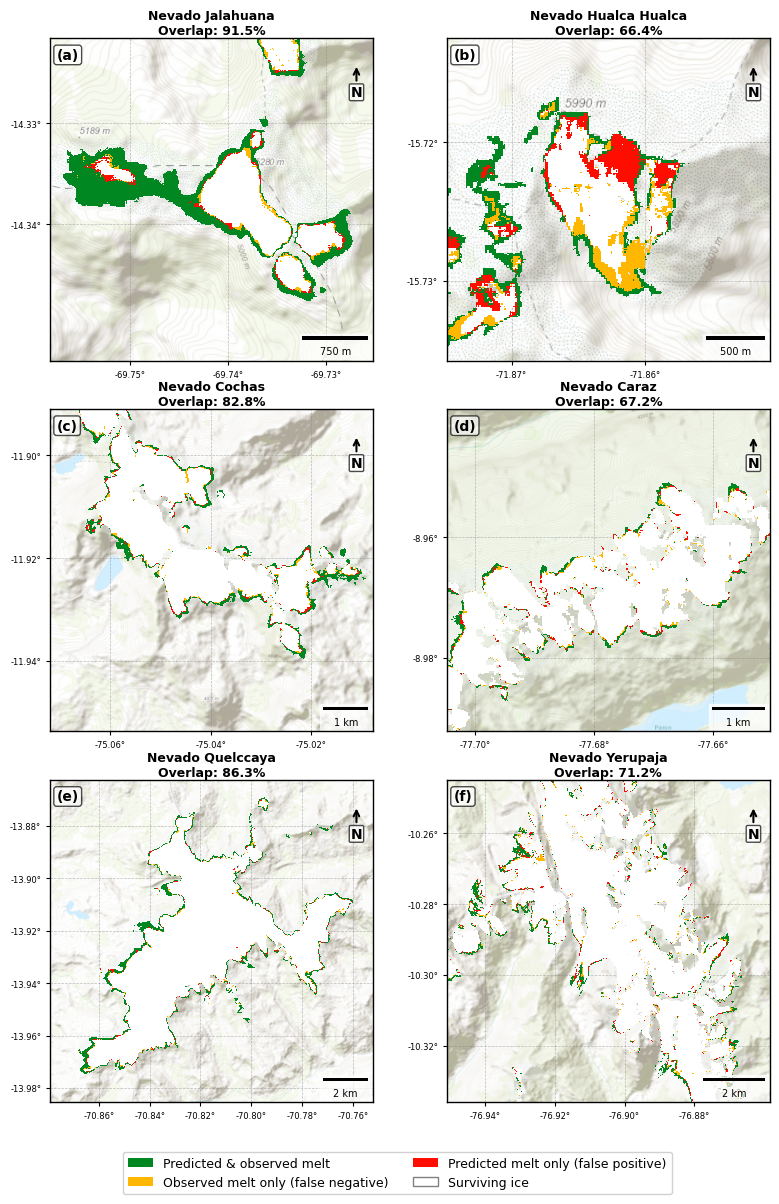

Panel saved


In [21]:
# ── Panel plot — same glaciers, same layout ───────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(10, 14),
                          gridspec_kw={'wspace': 0.05, 'hspace': 0.15})
axes_flat = axes.flatten()

for idx, (rgi_id, config) in enumerate(GLACIER_CONFIG.items()):
    print(f"Plotting {idx+1}/6: {config['name']} ({rgi_id})")
    result = compute_regional_overlap(rgi_id, df_2017_matched, df_selection,
                                   pad=config['pad'],
                                   load_pad=config.get('load_pad', None),
                                   lon_offset=config.get('lon_offset', 0.0),
                                   lat_offset=config.get('lat_offset', 0.0))
    overlap = result['overlap_pct'] if result else None
    plot_glacier_observed_vs_predicted(
        rgi_id, config['name'],
        df_2017_matched, df_selection,
        ax=axes_flat[idx],
        zoom=config['zoom'],
        pad=config['pad'],
        load_pad=config.get('load_pad', None),
        lon_offset=config.get('lon_offset', 0),
        lat_offset=config.get('lat_offset', 0),
        overlap_pct=overlap
    )
    axes_flat[idx].text(0.02, 0.97, f'({chr(97+idx)})',
                         transform=axes_flat[idx].transAxes,
                         fontsize=10, fontweight='bold',
                         va='top', color='black',
                         bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='white', alpha=0.7))

# Shared legend
handles = [
    mpatches.Patch(facecolor="#008722", label='Predicted & observed melt'),
    mpatches.Patch(facecolor="#ffb700", label='Observed melt only (false negative)'),
    mpatches.Patch(facecolor="#ff0d00", label='Predicted melt only (false positive)'),
    mpatches.Patch(facecolor='#ffffff', edgecolor='grey', label='Surviving ice'),
]

fig.legend(handles=handles,
           loc='lower center',
           ncol=2,
           fontsize=9,
           framealpha=0.9,
           bbox_to_anchor=(0.5, 0.05))  # increase second value to move legend up

plt.subplots_adjust(wspace=0.05, hspace=0.15, bottom=0.12)  # increase bottom to make room
plt.savefig(RESULTS_DIR / 'glacier_panel_observed_vs_predicted.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Panel saved")

In [164]:
def compute_regional_overlap(rgi_id, df_2017_matched, df_selection, 
                              pad, load_pad=None, 
                              lon_offset=0.0, lat_offset=0.0):
    """
    Compute overlap % for all ice pixels in the plotted bounding box,
    not just the target RGI polygon.
    """
    if load_pad is None:
        load_pad = pad
    
    # Get target glacier for bounding box
    target = df_2017_matched[df_2017_matched['rgi_id'] == rgi_id]
    if len(target) == 0:
        return None
    
    # Compute centre with offset
    centre_lon = target['lon'].mean() + lon_offset
    centre_lat = target['lat'].mean() + lat_offset
    
    # Load bounding box
    half_lon = (target['lon'].max() - target['lon'].min()) / 2 + load_pad
    half_lat = (target['lat'].max() - target['lat'].min()) / 2 + load_pad
    
    lon_min = centre_lon - half_lon
    lon_max = centre_lon + half_lon
    lat_min = centre_lat - half_lat
    lat_max = centre_lat + half_lat
    
    # All 2017 pixels in bounding box
    all_in_box = df_2017_matched[
        (df_2017_matched['lat'] >= lat_min) & (df_2017_matched['lat'] <= lat_max) &
        (df_2017_matched['lon'] >= lon_min) & (df_2017_matched['lon'] <= lon_max)
    ].copy().reset_index(drop=True)
    
    n_actual_melt = (all_in_box['melt_label'] == 1).sum()
    n_total       = len(all_in_box)
    
    if n_actual_melt == 0:
        return None
    
    # Calibrated top-N prediction across whole box
    top_n      = np.argsort(all_in_box['mlp_score'].values)[::-1][:n_actual_melt]
    pred_melt  = np.zeros(n_total, dtype=bool)
    pred_melt[top_n] = True
    actual_melt = all_in_box['melt_label'].values == 1
    
    n_intersect = (pred_melt & actual_melt).sum()
    overlap_pct = n_intersect / n_actual_melt * 100
    iou         = n_intersect / (pred_melt | actual_melt).sum()
    
    return {
        'rgi_id':        rgi_id,
        'n_pixels':      n_total,
        'n_melt':        n_actual_melt,
        'overlap_pct':   overlap_pct,
        'iou':           iou
    }

# Compute for all selected glaciers
print("Regional overlap (full plotted area):\n")
print(f"{'Glacier':<25} {'N pixels':>10} {'N melt':>8} "
      f"{'Overlap %':>10} {'IoU':>8}")
print("-" * 65)

for rgi_id, config in GLACIER_CONFIG.items():
    result = compute_regional_overlap(
        rgi_id, df_2017_matched, df_selection,
        pad=config['pad'],
        load_pad=config.get('load_pad', None),
        lon_offset=config.get('lon_offset', 0.0),
        lat_offset=config.get('lat_offset', 0.0)
    )
    if result:
        print(f"{config['name']:<25} {result['n_pixels']:>10,} "
              f"{result['n_melt']:>8,} {result['overlap_pct']:>9.1f}% "
              f"{result['iou']:>8.4f}")

Regional overlap (full plotted area):

Glacier                     N pixels   N melt  Overlap %      IoU
-----------------------------------------------------------------
Nevado Jalahuana              22,870   11,070      91.5%   0.8438
Nevado Hualca Hualca          25,571   14,668      66.4%   0.4975
Nevado Cochas                 95,203   12,612      82.8%   0.7064
XXXX                         192,222   13,552      67.2%   0.5060
Nevado Quelccaya             431,255   45,152      86.3%   0.7597
Nevado Yerupaja              383,481   28,384      71.2%   0.5533


In [ ]:
def plot_glacier_final(rgi_id, peak_name, df_melt, df_2017_matched,
                        df_selection, ax, pad=0.008, zoom=15,
                        lon_offset=0, lat_offset=0):
    """
    Plot projected melt 2025-2085 using imshow grid rendering.
    Observed melt 2017-2025 shown in dark navy on top.
    """
    stats  = df_selection[df_selection['rgi_id'] == rgi_id].iloc[0]
    target = df_melt[df_melt['rgi_id'] == rgi_id].copy()
    
    if len(target) == 0:
        print(f"No simulation pixels found for {rgi_id}")
        return
    
    # Get centre from target glacier with optional offset
    centre_lon = (target['lon'].mean() if 'melt_year' in target.columns 
                else target['lon'].mean())
    centre_lat = (target['lat'].mean() if 'melt_year' in target.columns 
                else target['lat'].mean())

    # Apply offset
    centre_lon += lon_offset
    centre_lat += lat_offset

    # Build bounding box around offset centre
    half_lon = (target['lon'].max() - target['lon'].min()) / 2 + pad
    half_lat = (target['lat'].max() - target['lat'].min()) / 2 + pad

    lon_min = centre_lon - half_lon
    lon_max = centre_lon + half_lon
    lat_min = centre_lat - half_lat
    lat_max = centre_lat + half_lat
    
    # All simulation pixels in bounding box
    all_in_box = df_melt[
        (df_melt['lat'] >= lat_min) & (df_melt['lat'] <= lat_max) &
        (df_melt['lon'] >= lon_min) & (df_melt['lon'] <= lon_max)
    ].copy().reset_index(drop=True)
    
    # Observed melt pixels in bounding box
    observed_in_box = df_2017_matched[
        (df_2017_matched['lat'] >= lat_min) & (df_2017_matched['lat'] <= lat_max) &
        (df_2017_matched['lon'] >= lon_min) & (df_2017_matched['lon'] <= lon_max) &
        (df_2017_matched['melt_label'] == 1)
    ].copy().reset_index(drop=True)
    
    # Assign projected melt colours
    all_in_box['plot_colour'] = None
    for year in TIMESTEPS:
        mask = all_in_box['melt_year'] == year
        all_in_box.loc[mask, 'plot_colour'] = MELT_COLOURS[year]
    
    # Observed melt overwrites projected colour (plotted on top)
    observed_in_box['plot_colour'] = '#1a1a4e'
    
    # Combine — observed on top
    combined = pd.concat([all_in_box, observed_in_box], ignore_index=True)
    # Drop duplicates keeping last (observed overwrites projected)
    combined = combined.drop_duplicates(subset=['lon', 'lat'], keep='last')
    
    # Set axis limits
    corners = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            [lon_min, lon_max], [lat_min, lat_max]
        ), crs='EPSG:4326'
    ).to_crs('EPSG:3857')
    ax.set_xlim(corners.geometry.x.min(), corners.geometry.x.max())
    ax.set_ylim(corners.geometry.y.min(), corners.geometry.y.max())
    
    # Basemap
    ctx.add_basemap(ax,
                    source=ctx.providers.Esri.WorldTopoMap,
                    zoom=zoom, alpha=0.9)
    
    # Remove attribution
    for artist in ax.get_children():
        if hasattr(artist, 'get_text'):
            if any(x in artist.get_text() for x in ['Esri', 'USGS', 'Tiles']):
                artist.set_visible(False)
    
    # Plot as grid
    plot_as_grid(combined, ax, lon_min, lat_min, lon_max, lat_max)
    
    # North arrow
    ax.annotate('N', xy=(0.95, 0.92), xytext=(0.95, 0.82),
                xycoords='axes fraction',
                fontsize=10, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.1',
                          facecolor='white', alpha=0.7))
    
    # Scale bar
    from matplotlib_scalebar.scalebar import ScaleBar
    scalebar = ScaleBar(1, units='m', dimension='si-length',
                        length_fraction=0.25, location='lower right',
                        box_alpha=0.7, color='black',
                        font_properties={'size': 7})
    ax.add_artist(scalebar)
    ax.set_aspect(1)
    
    # Gridlines
    lon_extent = lon_max - lon_min
    if lon_extent < 0.05:
        tick_spacing = 0.01
    elif lon_extent < 0.15:
        tick_spacing = 0.02
    else:
        tick_spacing = 0.05
    
    lon_ticks = np.arange(
        np.ceil(lon_min / tick_spacing) * tick_spacing,
        lon_max, tick_spacing)
    lat_ticks = np.arange(
        np.ceil(lat_min / tick_spacing) * tick_spacing,
        lat_max, tick_spacing)
    
    def lon_to_mx(lon):
        return gpd.GeoDataFrame(
            geometry=gpd.points_from_xy([lon], [0]),
            crs='EPSG:4326').to_crs('EPSG:3857').geometry.x[0]
    
    def lat_to_my(lat):
        return gpd.GeoDataFrame(
            geometry=gpd.points_from_xy([0], [lat]),
            crs='EPSG:4326').to_crs('EPSG:3857').geometry.y[0]
    
    ax.set_xticks([lon_to_mx(lon) for lon in lon_ticks])
    ax.set_yticks([lat_to_my(lat) for lat in lat_ticks])
    ax.set_xticklabels([f'{lon:.2f}°' for lon in lon_ticks], fontsize=6)
    ax.set_yticklabels([f'{lat:.2f}°' for lat in lat_ticks], fontsize=6)
    ax.tick_params(left=True, bottom=True, labelleft=True,
                   labelbottom=True, labelsize=6, length=3)
    ax.grid(True, color='gray', linewidth=0.5, alpha=0.5, linestyle='--')
    ax.set_title(peak_name, fontsize=9, pad=3, fontweight='bold')

Plotting 1/6: Nevado XXXX (RGI2000-v7.0-G-16-02683)
Plotting 2/6: Nevado XXXX (RGI2000-v7.0-G-16-00275)


/nvme1/users/md962/glacier/.venv/lib/python3.14/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Plotting 3/6: Nevado XXXX (RGI2000-v7.0-G-16-01349)


/nvme1/users/md962/glacier/.venv/lib/python3.14/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Plotting 4/6: Nevado XXXX (RGI2000-v7.0-G-16-02620)


/nvme1/users/md962/glacier/.venv/lib/python3.14/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Plotting 5/6: Nevado XXXX (RGI2000-v7.0-G-16-00836)


/nvme1/users/md962/glacier/.venv/lib/python3.14/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


Plotting 6/6: Nevado XXXX (RGI2000-v7.0-G-16-00617)


/nvme1/users/md962/glacier/.venv/lib/python3.14/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/nvme1/users/md962/glacier/.venv/lib/python3.14/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


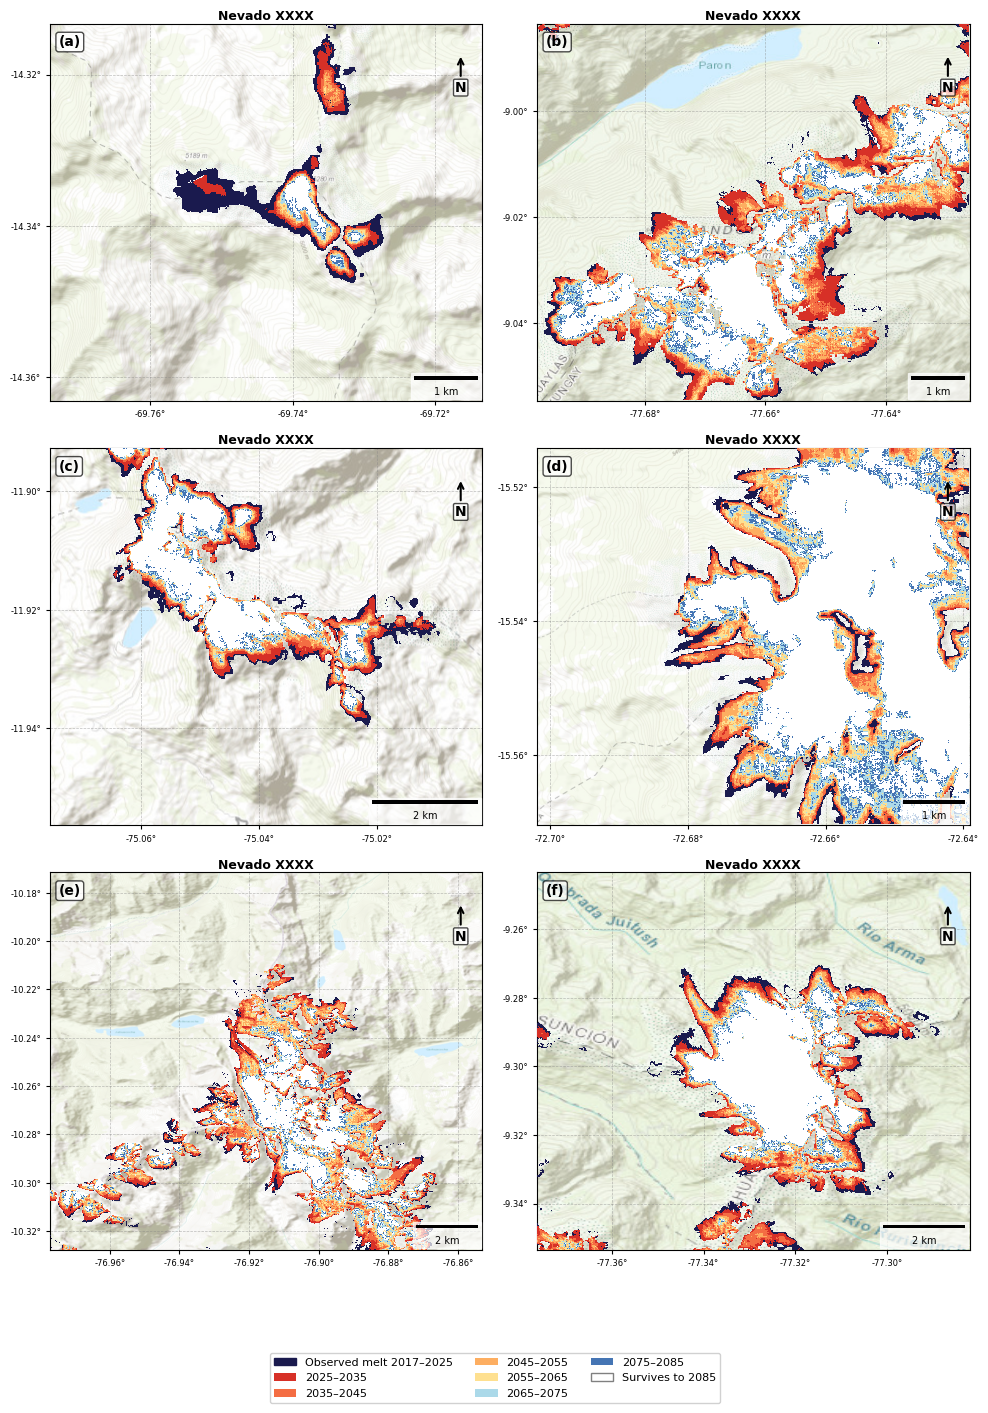

Panel saved


In [49]:
fig, axes = plt.subplots(3, 2, figsize=(10, 14))
axes_flat = axes.flatten()

for idx, (rgi_id, config) in enumerate(GLACIER_CONFIG.items()):
    print(f"Plotting {idx+1}/6: {config['name']} ({rgi_id})")
    plot_glacier_final(
        rgi_id, config['name'],
        df_melt, df_2017_matched, df_selection,
        ax=axes_flat[idx],
        zoom=config['zoom'],
        pad=config['pad']
    )
    axes_flat[idx].text(0.02, 0.97, f'({chr(97+idx)})',
                         transform=axes_flat[idx].transAxes,
                         fontsize=10, fontweight='bold',
                         va='top', color='black',
                         bbox=dict(boxstyle='round,pad=0.2',
                                   facecolor='white', alpha=0.7))

# Shared legend at bottom
melt_labels = {
    2035: '2025–2035',
    2045: '2035–2045',
    2055: '2045–2055',
    2065: '2055–2065',
    2075: '2065–2075',
    2085: '2075–2085',
    0:    'Survives to 2085'
}
handles = [mpatches.Patch(color='#1a1a4e', label='Observed melt 2017–2025')]
handles += [
    mpatches.Patch(
        facecolor=MELT_COLOURS[y],
        edgecolor='grey' if y == 0 else 'none',
        label=melt_labels[y]
    )
    for y in TIMESTEPS
]

fig.legend(handles=handles,
           loc='lower center',
           ncol=3,
           fontsize=8,
           framealpha=0.9,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(RESULTS_DIR / 'glacier_panel_final.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Panel saved")